In [ ]:
import pandas as pd
import numpy as np
pd.options.mode.copy_on_write = True

In [ ]:
np.set_printoptions(suppress=True)

In [ ]:
import seaborn as sns

**Define the Problem**

**Project Title**: *Does More Education Spending Drive National Development?*

Using two publicly available datasets:
- **World Bank Education Spending Data (2022)** (From the World Bank): Contains each country's public education expenditure as a % of GDP.
- **World Data 2023** (From Kaggle): Includes country-level development indicators such as GDP per capita, life expectancy, literacy rate, access to basic services, and employment statistics.

**The question statement is: Do countries that spend more on education tend to have better outcomes in development, as measured by a combination of social and economic indicators?**

This question cannot be answered by one dataset only because the education spending dataset only tells us how much countries spend, but not whether it matters, and the world development dataset gives us outcome metrics, but lacks education inputs.

In [ ]:
import pandas as pd

edu = pd.read_csv('worldbank-education-spending.csv', skiprows=4)
dev = pd.read_csv('world-data-2023.csv')

print("Education spending shape:", edu.shape)
print("World development shape:", dev.shape)

Education spending shape: (266, 70)
World development shape: (195, 35)


In [ ]:
edu.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,5.491360,4.456181,4.548759,4.435043,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,4.665563,4.878870,4.979931,4.944317,4.352440,4.771326,4.628624,NaN,NaN,NaN
2,Afghanistan,AFG,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,4.543970,4.343190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.667731,3.360854,3.023458,3.047400,3.398741,3.203484,2.905294,NaN,NaN,NaN
4,Angola,AGO,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.754937,2.466879,2.183513,2.073064,2.667447,2.297109,2.332126,NaN,NaN,NaN


In [ ]:
dev.head()

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.939110,67.709953
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626
3,Andorra,164,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469,...,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887


In [ ]:
# Keep only relevant columns
edu_clean = edu[['Country Name', '2022']].rename(columns={'Country Name': 'Country', '2022': 'EduSpending'})
edu_clean.dropna(inplace=True)

# Check result
edu_clean.head()

,Country,EduSpending
1,Africa Eastern and Southern,4.628624
3,Africa Western and Central,2.905294
4,Angola,2.332126
5,Albania,2.744330
6,Andorra,2.647290


In [ ]:
# Inspect development data country names
dev['Country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'The Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Ivory Coast',
       'Cape Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Republic of the Congo', 'Costa Rica', 'Croatia',
       'Cuba', 'Cyprus', 'Czech Republic',
       'Democratic Republic of the Congo', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon',
       'The Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Grenada',
       'Guatemal

In [ ]:
# Merge datasets on 'Country'
merged = pd.merge(dev, edu_clean, on='Country', how='inner')

# Check merged result
print("Merged shape:", merged.shape)
merged.head()

Merged shape: (114, 36)


,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude,EduSpending
0,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331,2.744330
1,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626,4.749247
2,Andorra,164,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469,...,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801,2.647290
3,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887,2.332126
4,Antigua and Barbuda,223,AG,20.50%,443,0,15.33,1.0,"St. John's, Saint John",557,...,2.76,"97,118",NaN,16.50%,43.00%,NaN,"23,800",17.060816,-61.796428,3.647748


In [ ]:
# Clean GDP: remove $, commas, and whitespace
merged['GDP'] = (
    merged['GDP']
    .astype(str)                         # ensure it's all strings
    .str.replace('$', '', regex=False)  # remove dollar signs
    .str.replace(',', '', regex=False)  # remove commas
    .str.strip()                        # remove whitespace
    .astype(float)                      # convert to float
)

# Clean Population (remove commas and whitespace)
merged['Population'] = (
    merged['Population']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

# Create GDP per capita
merged['GDP per capita'] = merged['GDP'] / merged['Population']

In [ ]:
merged[['Country', 'GDP', 'Population', 'GDP per capita']].head()

,Country,GDP,Population,GDP per capita
0,Albania,1.527808e+10,2854191.0,5352.857411
1,Algeria,1.699882e+11,43053054.0,3948.343279
2,Andorra,3.154058e+09,77142.0,40886.391162
3,Angola,9.463542e+10,31825295.0,2973.591160
4,Antigua and Barbuda,1.727759e+09,97118.0,17790.309304


In [ ]:
# List of all numeric columns for PCA
numeric_columns = [
    'GDP per capita',
    'Life expectancy',
    'Gross primary education enrollment (%)',
    'Gross tertiary education enrollment (%)',
    'Infant mortality',
    'Unemployment rate',
    'Urban_population'
]

# Remove commas and percentage signs from all columns
for col in numeric_columns:
    merged[col] = (
        merged[col]
        .astype(str)
        .str.replace(',', '', regex=False)  # remove commas
        .str.replace('%', '', regex=False)  # remove percentage signs
        .str.strip()                        # remove whitespace
        .replace('', 'NaN')                 # replace empty strings
        .astype(float)
    )

In [ ]:
merged['Life expectancy'] = merged['Life expectancy'].astype(float)
merged['Infant mortality'] = merged['Infant mortality'].astype(float)
merged['GDP per capita'] = merged['GDP per capita'].astype(float)

In [ ]:
# Select numeric features for PCA
features = [
    'Life expectancy',
    'GDP per capita',
    'Gross primary education enrollment (%)',
    'Gross tertiary education enrollment (%)',
    'Infant mortality',
    'Unemployment rate',
    'Urban_population'
]
data = merged[features]

# Normalize data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

In [ ]:
# Drop rows with missing values in the features
data = merged[features].replace([float('inf'), -float('inf')], pd.NA).dropna()

merged_clean = merged.loc[data.index].copy()

# Normalize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

merged_clean['PC1'] = X_pca[:, 0]
merged_clean['PC2'] = X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.44752267 0.15813048]


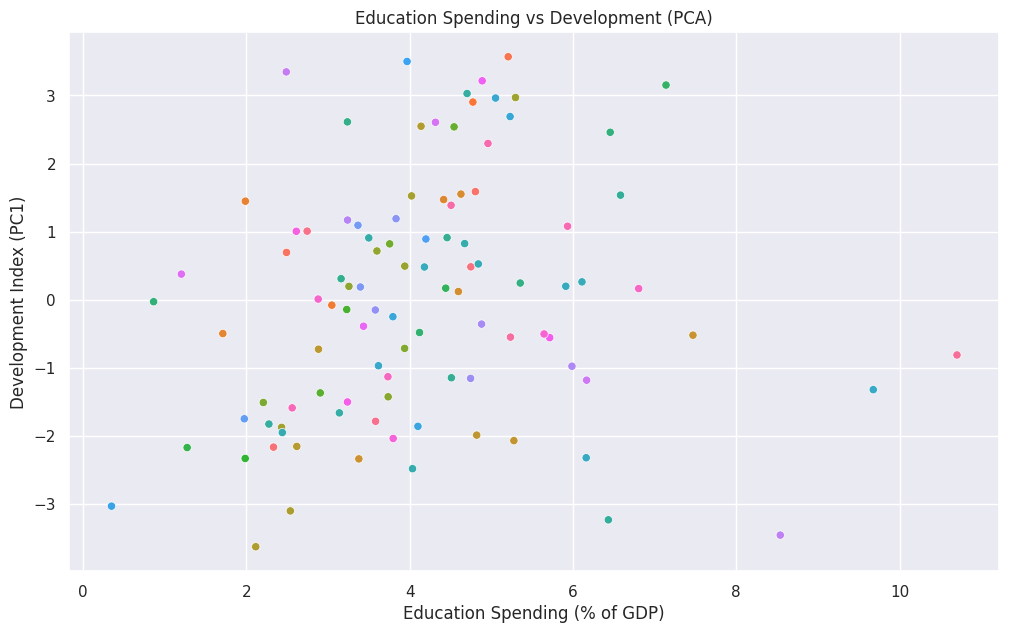

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=merged_clean,
    x='EduSpending',
    y='PC1',
    hue='Country',   # optional: color by country
    legend=False
)

plt.xlabel('Education Spending (% of GDP)')
plt.ylabel('Development Index (PC1)')
plt.title('Education Spending vs Development (PCA)')
plt.grid(True)
plt.show()

My analysis shows that higher education spending as a percentage of GDP is generally associated with better development outcomes, but the relationship is not perfect. The outliers highlight that factors beyond spending, such as policy effectiveness and resource allocation, also play a key role in shaping development.

In [ ]:
!jupyter nbconvert --to html /content/Raabya_Vasandani_Assignment_2.ipynb

[NbConvertApp] Converting notebook /content/Raabya_Vasandani_Assignment_2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 14 image(s).
[NbConvertApp] Writing 6365700 bytes to /content/Raabya_Vasandani_Assignment_2.html
